In [1]:
import torch
from sdf_utils import sap
import time
import random
import deep_sdf
from deep_sdf import mesh, metrics, lr_scheduling, plotting, utils, loss, data
import deep_sdf.workspace as ws
import json
import os
import reconstruct
import numpy as np
import matplotlib.pyplot as plt
import networks.sdf_vae as vae
import logging

In [3]:
def get_spec_with_default(specs, key, default):
    try:
        return specs[key]
    except KeyError:
        return default

In [4]:
#experiment_directory = "examples/torus/Run_w_con_loss_one_variable_usual"
experiment_directory = "examples/torus_subgroup/only_KL_loss_without_supervision"
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
test_split_file = specs["TestSplit"]
train_split_file = specs["TrainSplit"]
data_source_mesh = specs["DataSourceMesh"]
with open(test_split_file, "r") as f:
    test_split = json.load(f)
eval_test_scene_num = get_spec_with_default(specs, "EvalTestSceneNumber", 10)
eval_test_optimization_steps = get_spec_with_default(specs, "EvalTestOptimizationSteps", 1000)
eval_grid_res = get_spec_with_default(specs, "EvalGridResolution", 256)
torus_path = get_spec_with_default(specs, "TorusPath", "/home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/scaled_obj_files")

In [5]:
arch = __import__("networks." + specs["NetworkArch"], fromlist=["Decoder"])
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = True

#decoder = arch.Decoder(latent_size, **specs["NetworkSpecs"])
decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
#decoder = torch.nn.DataParallel(decoder)

saved_model_state = torch.load(
    os.path.join(
        experiment_directory, ws.model_params_subdir, "latest" + ".pth"
    )
)
saved_model_epoch = saved_model_state["epoch"]

decoder.load_state_dict(saved_model_state["model_state_dict"])
#decoder = decoder.module.cuda()
decoder.eval()

SDFVAE(
  (encoder): DataParallel(
    (module): ResnetPointnet(
      (fc_pos): Linear(in_features=3, out_features=256, bias=True)
      (block_0): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_1): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_2): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_3): ResnetBlockFC(
        

In [6]:
eval_test_time_start = time.time()
test_err_sum = 0.
chamfer_dists = []
chamfer_dists_all = []
test_loss_hists = []
mesh_label_names = []
test_latents = []
sap_scores = []
all_labels = []
all_labels_reg = []
all_labels_group = []
all_latents = []

In [7]:
with open(train_split_file, "r") as f:
    train_split = json.load(f)

In [8]:
#eval_test_filenames = deep_sdf.data.get_instance_filenames(data_source, test_split)
eval_test_filenames = deep_sdf.data.get_instance_filenames(data_source, train_split)
labels = torch.load(data_source + "/labels.pt")
#eval_test_filenames = random.sample(eval_test_filenames, max(eval_test_scene_num, len(eval_test_filenames)))

In [9]:
len(eval_test_filenames)

400

In [10]:
for test_fname in eval_test_filenames:
    save_name = os.path.basename(test_fname).split(".npz")[0]
    mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
    test_surface_points = data.get_surface_points(mesh_path)
    test_surface_points = torch.from_numpy(test_surface_points)
    test_surface_points = test_surface_points.unsqueeze(0)
    label = labels.get(save_name)
    all_labels.append(label[0])
    all_labels_reg.append(label[2])
    all_labels_group.append(label[4])
    mesh_label_names.append(save_name)
    path = os.path.join(experiment_directory, "all_unsupervised", ws.tb_logs_test_reconstructions, save_name)
    if not os.path.exists(path):
        os.makedirs(path)
        
    test_fpath = os.path.join(data_source, ws.sdf_samples_subdir, test_fname)
    test_sdf_samples = deep_sdf.data.read_sdf_samples_into_ram(test_fpath)
    test_sdf_samples[0] = test_sdf_samples[0][torch.randperm(test_sdf_samples[0].shape[0])]
    test_sdf_samples[1] = test_sdf_samples[1][torch.randperm(test_sdf_samples[1].shape[0])]
 
    print(f"Creating mesh for {test_fname}...")
    test_latent = None
    start = time.time()
    with torch.no_grad():
        test_mesh, z = mesh.create_mesh(
            decoder, 
            kl_div_loss,
            test_surface_points,
            test_latent, 
            N=eval_grid_res, 
            max_batch=int(2 ** 18), 
            filename=os.path.join(path, f"epoch={saved_model_epoch}"),
            return_trimesh=True,
            return_latent=True
        )
    print(f"Mesh creation for {test_fname} took {time.time()-start} seconds.")

    all_latents.append(z)

    if test_mesh is not None:
        gt_mesh_path = f"{torus_path}/{save_name}.obj"
        cd, cd_all = metrics.compute_metric(gt_mesh=gt_mesh_path, gen_mesh=test_mesh, metric="chamfer")
        chamfer_dists.append(cd)
        chamfer_dists_all.append(cd_all)

        del test_sdf_samples, test_mesh

Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_0505.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_0505.npz took 7.7264204025268555 seconds.
Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3796.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3796.npz took 5.585065841674805 seconds.
Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_4084.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_b

In [12]:
# Create a directory to store the metrics
metrics_dir = os.path.join(experiment_directory, "metrics")
os.makedirs(metrics_dir, exist_ok=True)

# Save the aggregated Chamfer distances
chamfer_path = os.path.join(metrics_dir, "chamfer_dists.npy")
np.save(chamfer_path, np.array(chamfer_dists))
print(f"Saved aggregated Chamfer distances to {chamfer_path}")

# Save the detailed point-wise Chamfer distances
chamfer_all_path = os.path.join(metrics_dir, "chamfer_dists_all.npy")
np.save(chamfer_all_path, np.array(chamfer_dists_all, dtype=object))
print(f"Saved detailed Chamfer distances to {chamfer_all_path}")

# Save the mapping between mesh names and their Chamfer distances
mesh_chamfer_mapping = {name: dist for name, dist in zip(mesh_label_names, chamfer_dists)}
with open(os.path.join(metrics_dir, "mesh_chamfer_mapping.json"), 'w') as f:
    json.dump(mesh_chamfer_mapping, f, indent=4)
print(f"Saved mesh to Chamfer distance mapping")

# Save all latents
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.stack([l.detach().cpu().numpy() for l in all_latents], axis=0)
np.save(latents_path, all_latents_array)
print(f"Saved all latents to {latents_path}")

Saved aggregated Chamfer distances to examples/torus_subgroup/only_KL_loss_without_supervision/metrics/chamfer_dists.npy
Saved detailed Chamfer distances to examples/torus_subgroup/only_KL_loss_without_supervision/metrics/chamfer_dists_all.npy
Saved mesh to Chamfer distance mapping
Saved all latents to examples/torus_subgroup/only_KL_loss_without_supervision/metrics/all_latents.npy


In [35]:
metrics_dir = os.path.join(experiment_directory, "metrics")
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.load(latents_path)
print(f"Shape of all latents: {all_latents_array.shape}")

Shape of all latents: (306, 1, 16)


In [18]:
all_latents_array = all_latents_array.squeeze()
all_latents_array

array([[ 0.01829528, -0.04217457, -0.00907469, ..., -0.01147716,
         0.0007254 , -0.02430417],
       [-0.0189581 ,  0.01397205,  0.01666953, ...,  0.03229386,
        -0.00922419, -0.00159078],
       [-0.02634532, -0.01603323, -0.03729411, ...,  0.02240724,
        -0.03000078,  0.02916975],
       ...,
       [ 0.04330662, -0.02477818, -0.02196095, ..., -0.00240403,
         0.04765427, -0.0346414 ],
       [ 0.00268998, -0.01650911, -0.00283005, ...,  0.02323372,
        -0.02416984,  0.00331705],
       [-0.01325654,  0.03514403,  0.01719969, ..., -0.04673251,
        -0.01460284, -0.00875875]], dtype=float32)

In [ ]:
np.mean(chamfer_dists)

0.018840912101223593

In [25]:
# for training sap score using train latents
latent_vectors = ws.load_latent_vectors(experiment_directory, "latest")

In [26]:
test_latents = latent_vectors.numpy()
test_latents

array([[-0.575435  , -0.6429782 ,  0.21160646, ...,  0.03933862,
        -0.24190675, -0.07234324],
       [-0.57545424,  0.69773245, -0.15127687, ..., -0.00168114,
        -0.10183123,  0.03091359],
       [ 0.5672975 , -0.08133214,  0.3046311 , ...,  0.1310711 ,
         0.1707137 ,  0.14857425],
       ...,
       [-0.5754347 , -0.22443031,  0.06833063, ..., -0.00332314,
         0.0990525 , -0.08580769],
       [ 0.567255  ,  0.70041424, -0.17240226, ..., -0.09431293,
         0.14982753,  0.07370416],
       [ 0.56730896,  0.74855626,  0.07426561, ..., -0.04787093,
         0.2086435 ,  0.08448878]], dtype=float32)

In [27]:
# Extract the base names (without .obj extension)
keys_to_extract = [name.replace('.obj', '') for name in train_split_file]
# Extract third column values for matching keys
third_column_values = []
first_column_values = []    
for key in keys_to_extract:
    if key in labels:  # Check if the key exists in the large label file
        third_column_values.append(labels[key][2])  # Get the third column value
        first_column_values.append(labels[key][0])

In [28]:
print(third_column_values)

[0.2575250836120402, 0.7591973244147154, 0.4816053511705687, 0.15719063545150513, 0.2876254180602005, 0.030100334448160737, 0.5183946488294313, 0.632107023411371, 0.8227424749163874, 0.2876254180602005, 0.45484949832775934, 0.6889632107023416, 0.41137123745819393, 0.7458193979933108, 0.8561872909698991, 0.5551839464882944, 0.9732441471571907, 0.3143812709030098, 0.5150501672240804, 0.7224080267558524, 0.15719063545150513, 0.6053511705685617, 0.056856187290970084, 0.9832775919732439, 0.6220735785953178, 0.7458193979933108, 0.38127090301003363, 0.7290969899665547, 0.2775919732441472, 0.14046822742474951, 0.6923076923076921, 0.3712374581939799, 0.18729096989966543, 0.7257525083612038, 0.5986622073578594, 0.6153846153846154, 0.3377926421404682, 0.7157190635451509, 0.08695652173913082, 0.11036789297658878, 0.9030100334448159, 0.2742474916387958, 0.1705685618729098, 0.9866220735785953, 0.5384615384615383, 0.6387959866220734, 0.57190635451505, 0.6153846153846154, 0.5652173913043477, 0.6755852

In [29]:
len(third_column_values), len(first_column_values)

(369, 369)

In [30]:
all_labels = np.array(first_column_values)
all_labels_reg = np.array(third_column_values)

In [ ]:
# for test latents and sap score
test_latents = torch.cat(test_latents)
test_latents = test_latents.cpu().detach().numpy()

In [13]:

all_labels = np.array(all_labels)
all_labels_reg = np.array(all_labels_reg)
all_labels_group = np.array(all_labels_group)

In [8]:
path = os.path.join(experiment_directory, "test_latents", "latent_vectors.npy")

In [ ]:
np.save(path, test_latents)

In [17]:
all_labels = all_labels.reshape(-1, 1)
all_labels_reg = all_labels_reg.reshape(-1, 1)
all_labels_group = all_labels_group.reshape(-1, 1)

In [39]:
print(f"Calculating SAP scores...")
print(f"latent size: {all_latents_array.shape}")
print(f"all_labels size: {all_labels.shape}")
print(f"all_labels_reg size: {all_labels_reg.shape}")
print(f"all_labels_group size: {all_labels_group.shape}")
sap_score_cls = sap(factors=all_labels, codes=all_latents_array, continuous_factors=False, regression=False)
sap_score_reg = sap(factors=all_labels_reg, codes=all_latents_array, continuous_factors=True, regression=True)
sap_score_group = sap(factors=all_labels_group, codes=all_latents_array, continuous_factors=False, regression=False)

Calculating SAP scores...
latent size: (306, 16)
all_labels size: (307, 1)
all_labels_reg size: (307, 1)
all_labels_group size: (307, 1)


ValueError: Found input variables with inconsistent numbers of samples: [306, 307]

In [39]:
# contrastive vae
print(f"SAP score (classification): {sap_score_cls}")
print(f"SAP score (regression): {sap_score_reg}")
print(f"SAP score (group): {sap_score_group}")

SAP score (classification): 0.10999999999999999
SAP score (regression): 0.08654347512920024
SAP score (group): 0.010000000000000009


Data shapes before plotting:
all_latents_array: (400, 16)
all_labels: (400, 1)
all_labels_reg: (400, 1)
all_labels_group: (400, 1)
Processing Binary Class: 400 valid data points
  Unique values: [0. 1.]
  Is continuous: True


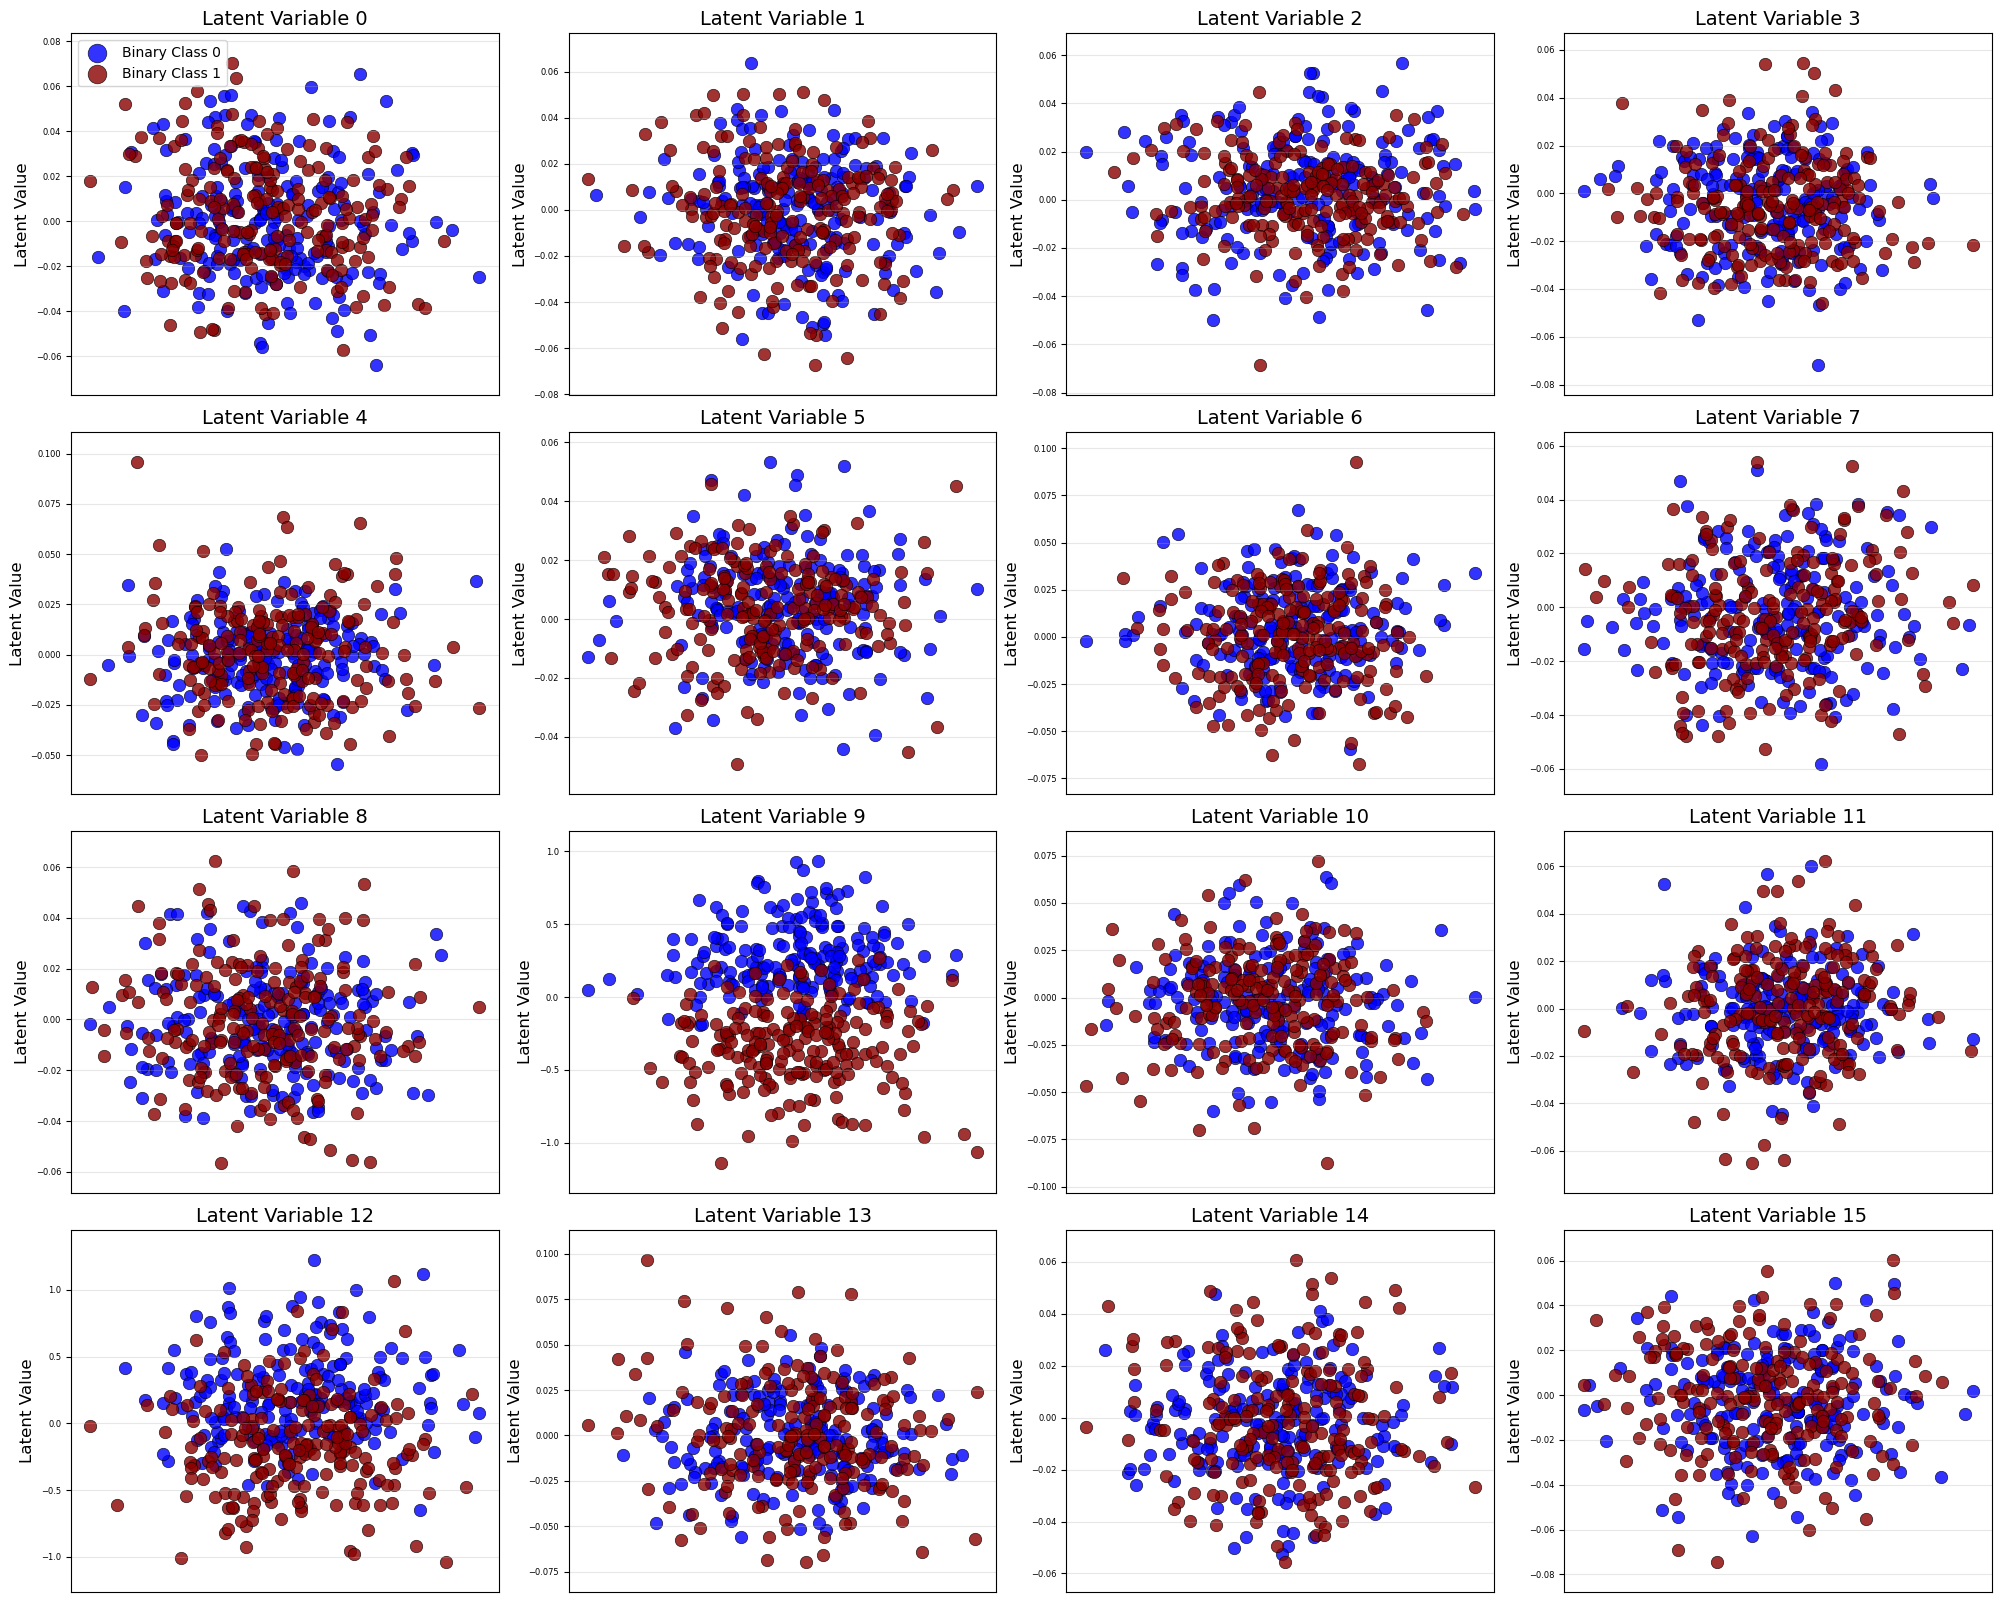

Processing Regression Value: 400 valid data points
  Unique values: [0.         0.00334448 0.00668896 0.01003344 0.01337793 0.01672241
 0.02006689 0.02341137 0.02675585 0.03010033 0.0367893  0.04347826
 0.05685619 0.06354515 0.06688963 0.07023411 0.0735786  0.07692308
 0.08361204 0.08695652 0.090301   0.09364548 0.10033445 0.10367893
 0.10702341 0.12040134 0.12374582 0.1270903  0.13043478 0.13377926
 0.14046823 0.14381271 0.14715719 0.15050167 0.15384615 0.15719064
 0.1638796  0.16722408 0.17056856 0.17391304 0.17725753 0.18060201
 0.18394649 0.18729097 0.19063545 0.19397993 0.21070234 0.21404682
 0.22408027 0.23076923 0.23411371 0.24080268 0.24414716 0.25083612
 0.2541806  0.26086957 0.26755853 0.27090301 0.27424749 0.28093645
 0.28428094 0.28762542 0.2909699  0.29431438 0.29765886 0.30434783
 0.30769231 0.31103679 0.31438127 0.31772575 0.32107023 0.32441472
 0.3277592  0.33110368 0.33444816 0.33779264 0.34113712 0.34448161
 0.34782609 0.35117057 0.35785953 0.36120401 0.37458194 0.377

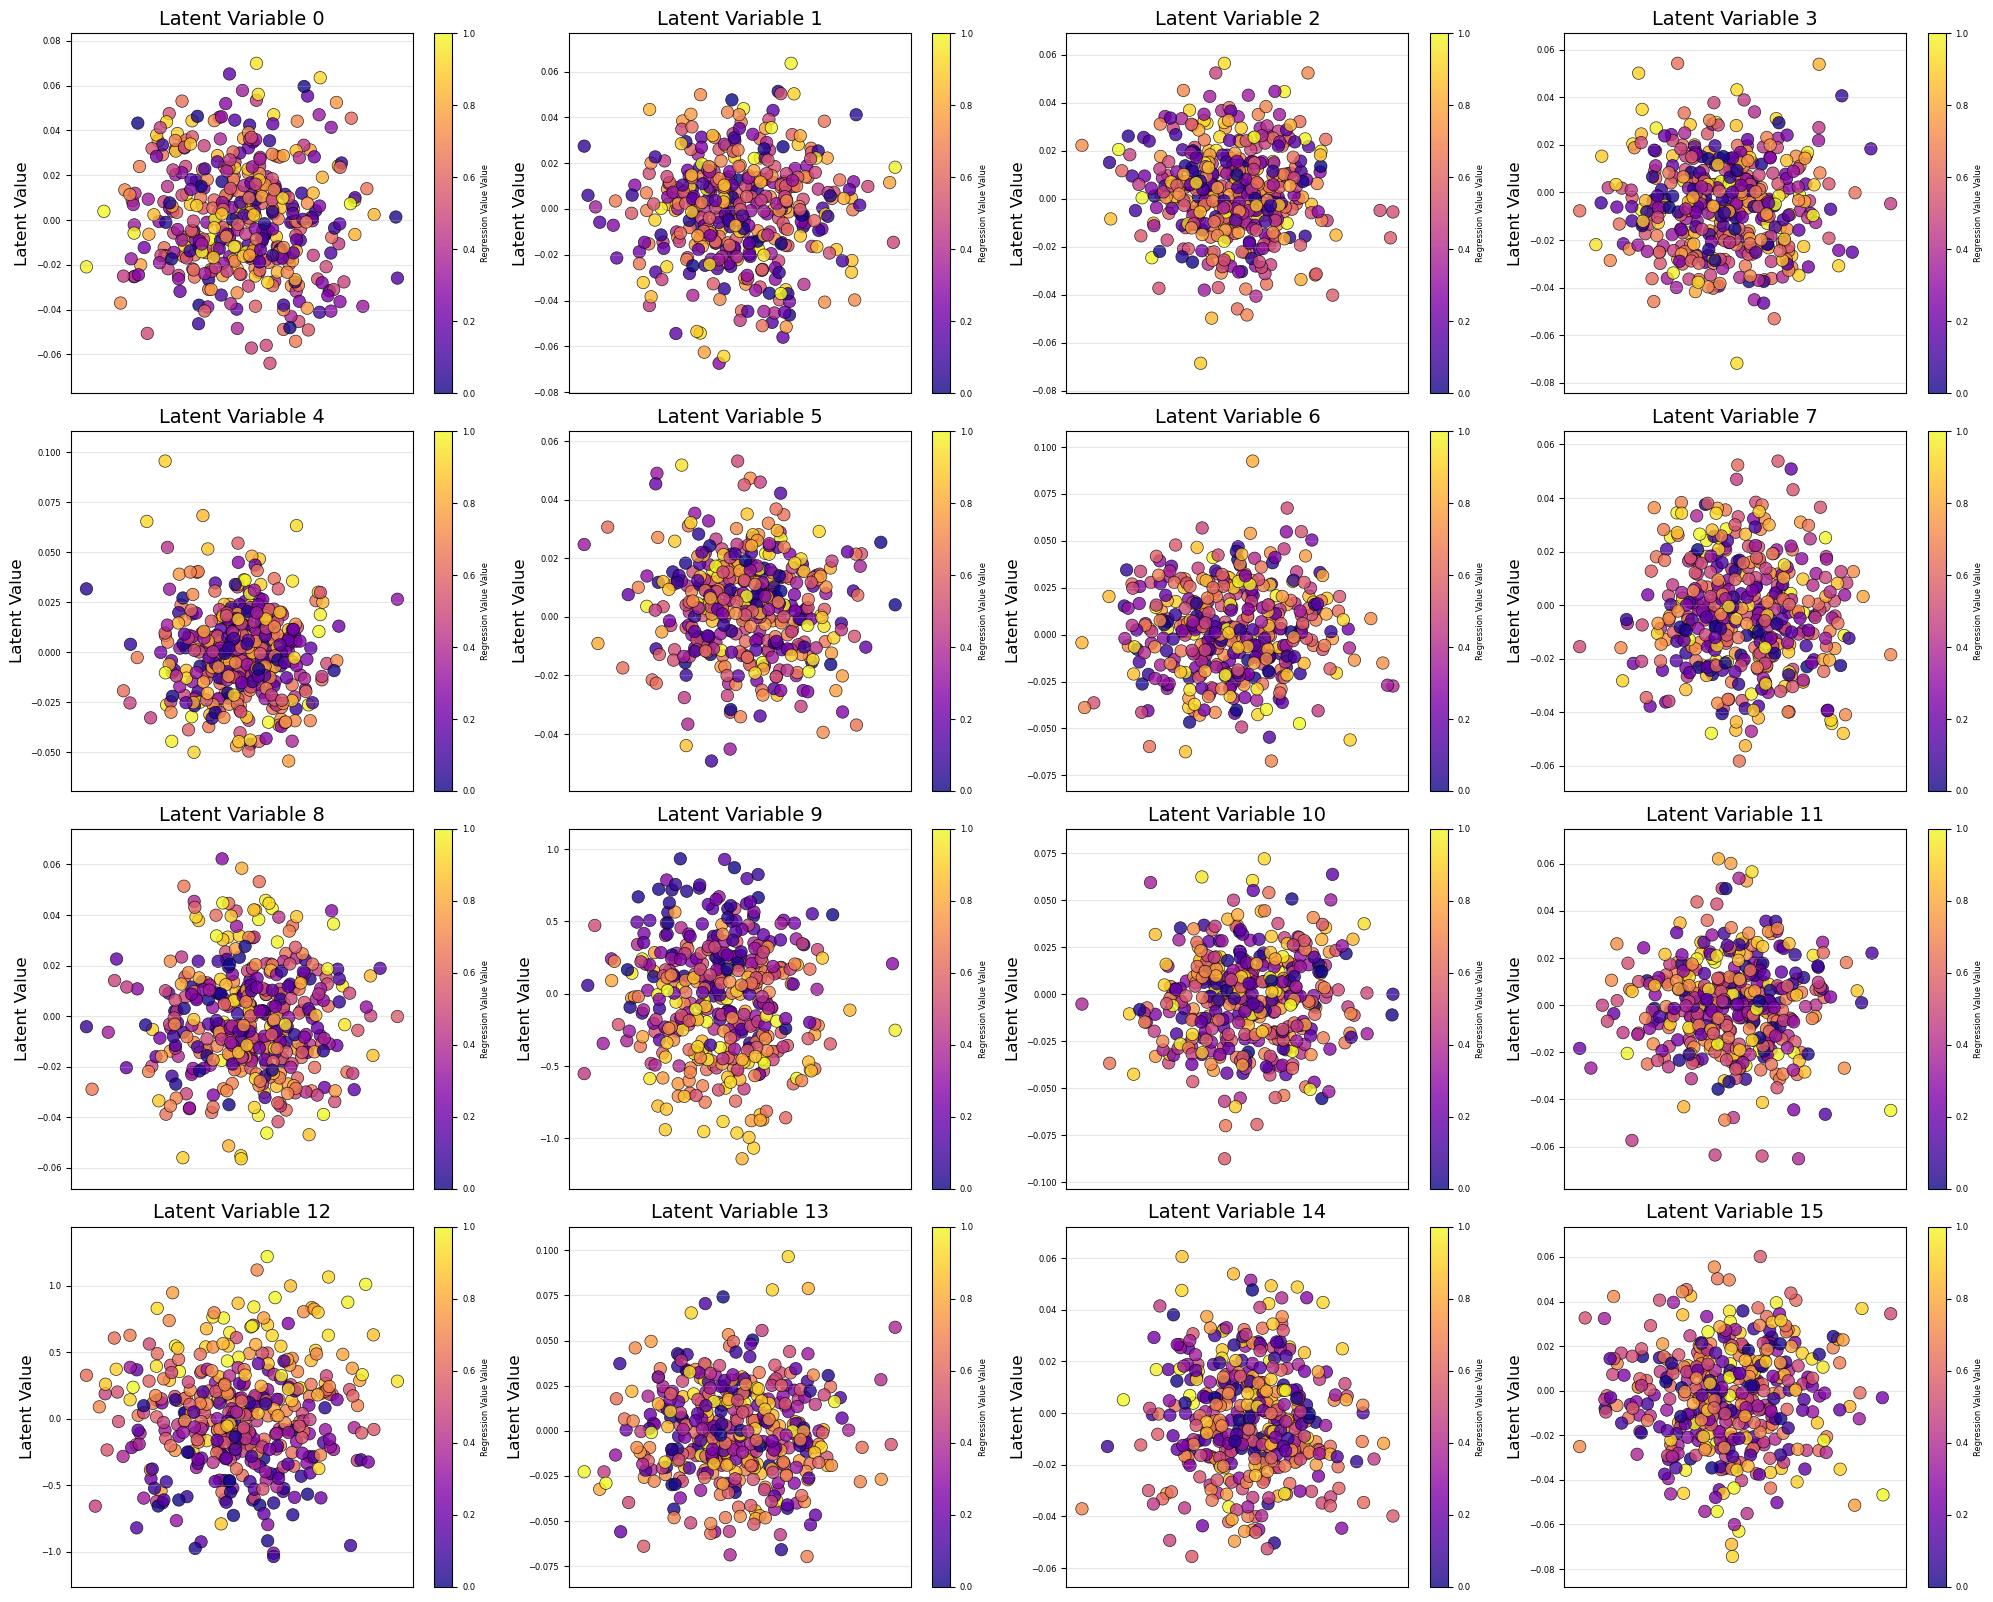

Processing Group: 400 valid data points
  Unique values: [1. 2.]
  Is continuous: True


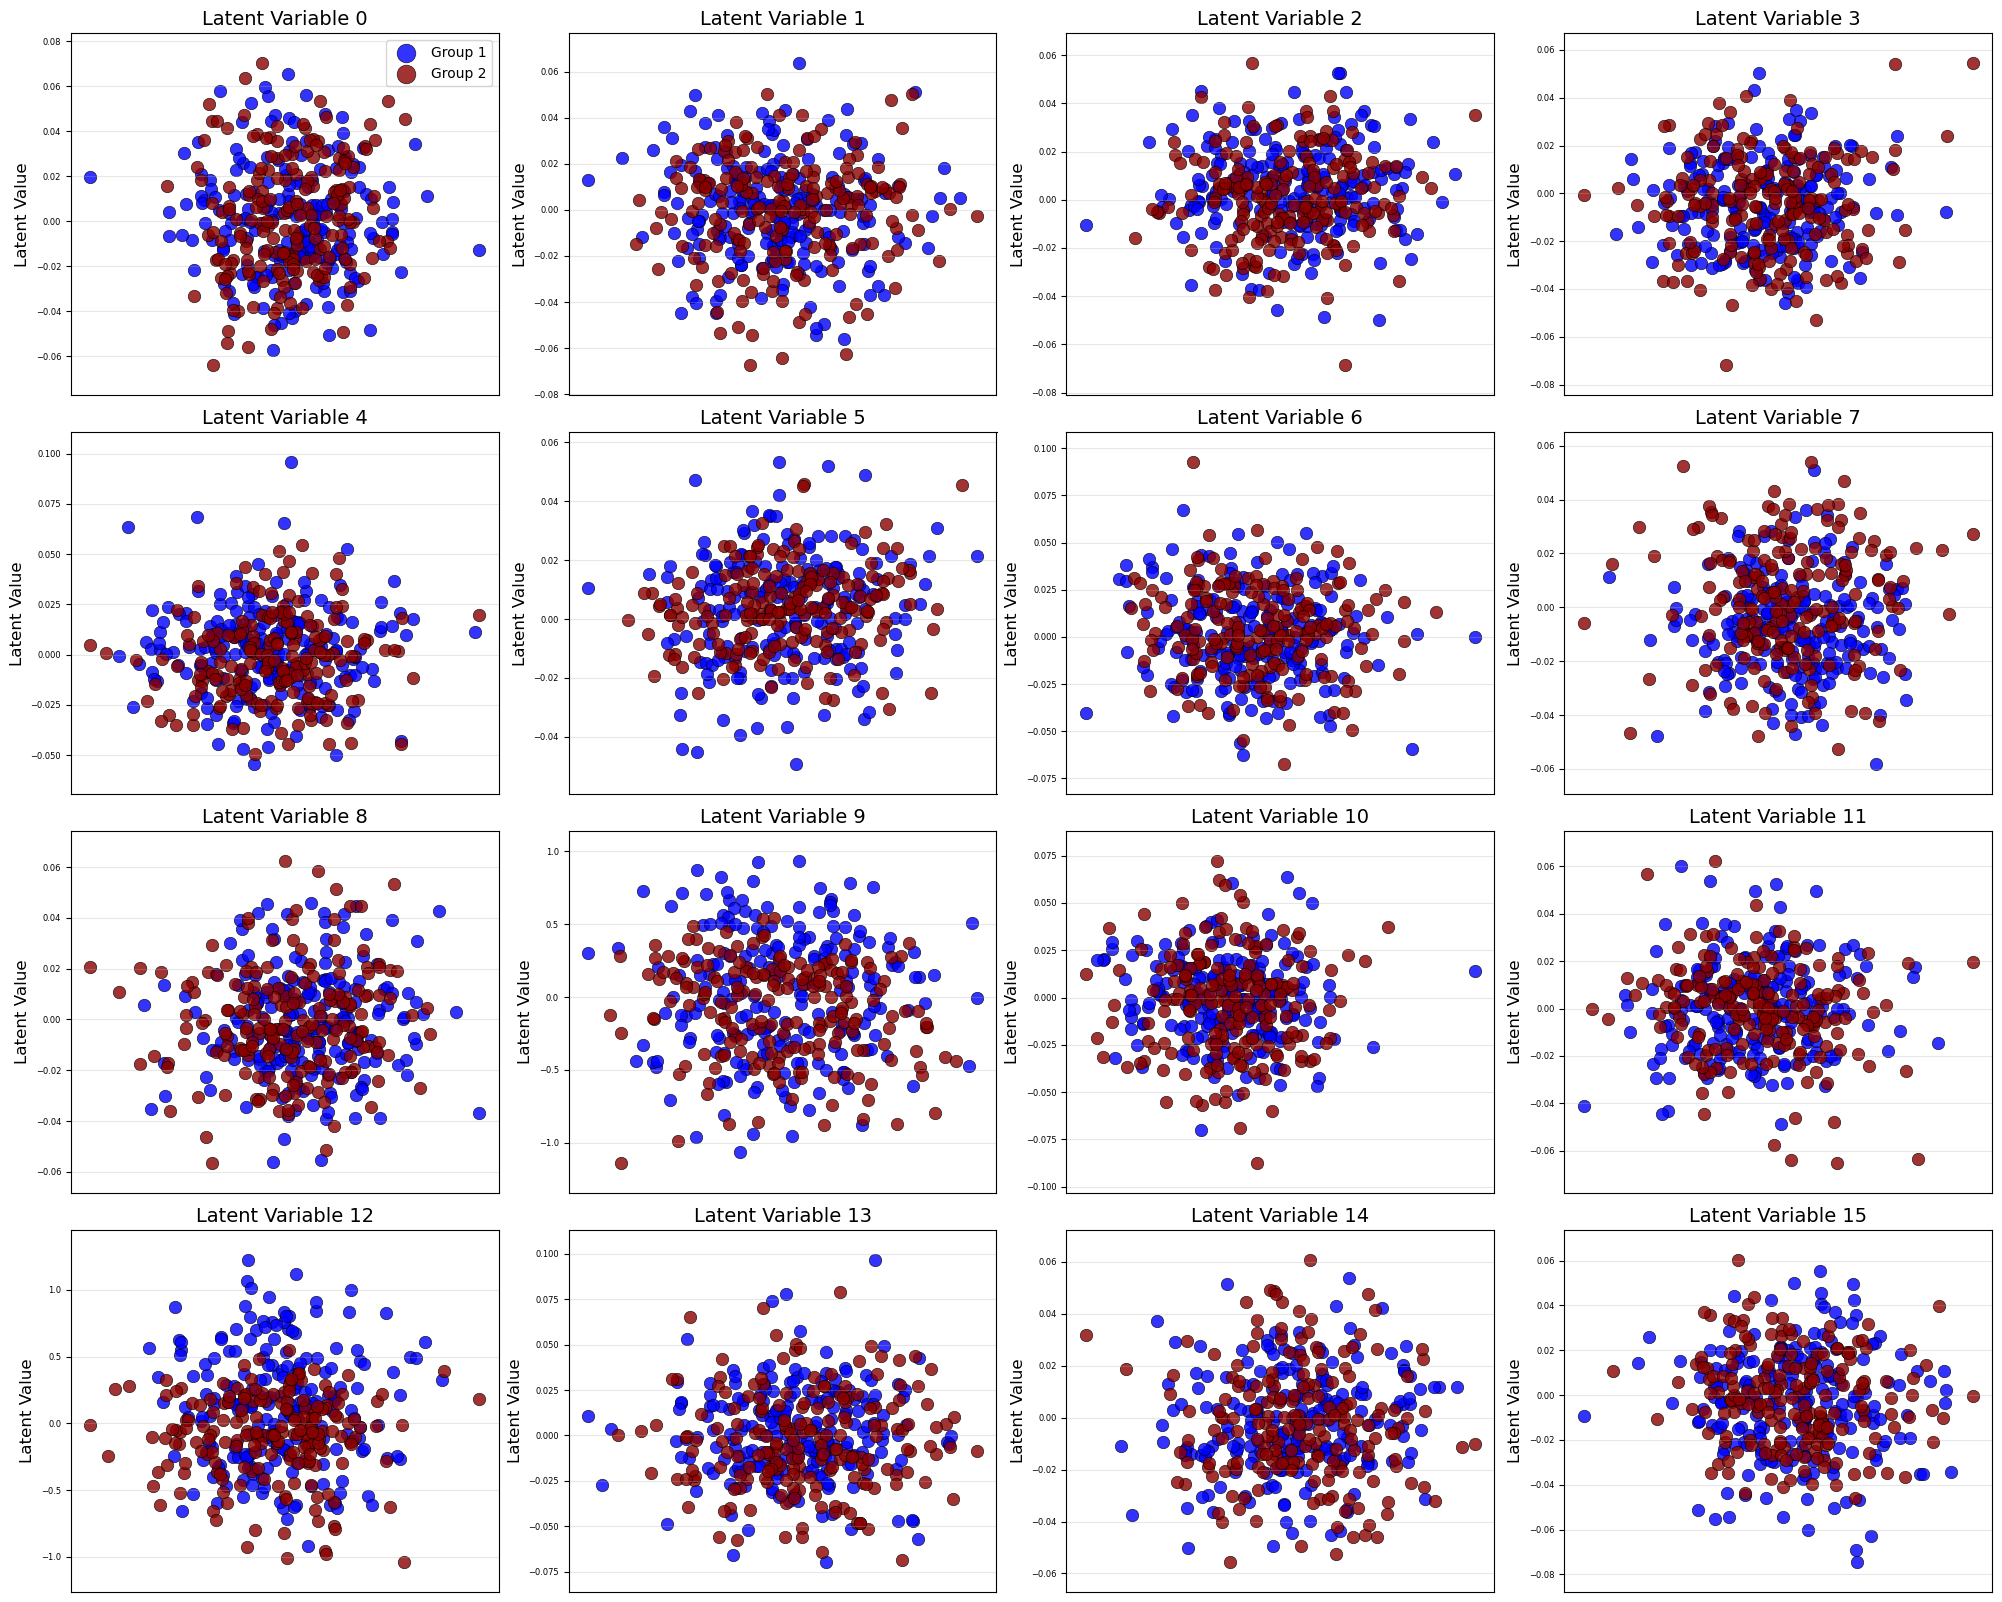

In [19]:
def plot_latent_scatter_by_label(all_latents_array, label_data, label_type, cmap=None):
    """
    Plot scatter plots for all latent variables colored by the given label type.
    
    Args:
        all_latents_array: Array of latent vectors (n_samples x n_dimensions)
        label_data: Array of labels to color points by
        label_type: String name of label type (for title and filename)
        cmap: Optional colormap for continuous values
    """
    # Ensure inputs are numpy arrays
    if not isinstance(all_latents_array, np.ndarray):
        all_latents_array = np.array(all_latents_array)
    if not isinstance(label_data, np.ndarray):
        label_data = np.array(label_data)
    
    # Flatten labels for coloring
    labels_flat = label_data.flatten()
    
    # Check for dimension mismatch first
    if len(labels_flat) != all_latents_array.shape[0]:
        print(f"Warning: Shape mismatch for {label_type}")
        print(f"  Labels shape: {labels_flat.shape}, Latents shape: {all_latents_array.shape}")
        # Try to match the smaller dimension
        min_len = min(len(labels_flat), all_latents_array.shape[0])
        labels_flat = labels_flat[:min_len]
        all_latents_array = all_latents_array[:min_len]
        print(f"  Truncated to length: {min_len}")
    
    # Remove any NaN or invalid values, but ensure both arrays are filtered identically
    # Check for NaN in labels
    valid_labels_mask = ~np.isnan(labels_flat)
    # Check for NaN in any latent dimension
    valid_latents_mask = ~np.isnan(all_latents_array).any(axis=1)
    # Combine masks
    valid_mask = valid_labels_mask & valid_latents_mask
    
    labels_flat = labels_flat[valid_mask]
    all_latents_filtered = all_latents_array[valid_mask]
    
    if len(labels_flat) == 0:
        print(f"Warning: No valid data points for {label_type}")
        return
    
    print(f"Processing {label_type}: {len(labels_flat)} valid data points")
    
    # Unique values for categorical coloring
    unique_values = np.unique(labels_flat)
    is_continuous = len(unique_values) > 10 or np.issubdtype(labels_flat.dtype, np.floating)
    
    print(f"  Unique values: {unique_values}")
    print(f"  Is continuous: {is_continuous}")
    
    # Improved color scheme - better visibility than yellow
    categorical_colors = ['blue', 'darkred', 'darkgreen', 'purple', 'darkorange', 'magenta', 'brown']
    
    plt.figure(figsize=(20, 16))
    
    for i in range(all_latents_filtered.shape[1]):
        plt.subplot(4, 4, i+1)
        
        # Get values for this latent dimension
        latent_values = all_latents_filtered[:, i]
        
        # Add jitter to x-axis for better visualization
        x_jitter = np.random.normal(0, 0.1, size=len(latent_values))
        
        # Create scatter plot based on label type
        if is_continuous and cmap is not None:
            # Continuous coloring (regression values) - only use cmap when provided
            if len(latent_values) > 0:  # Check if we have data
                scatter = plt.scatter(x_jitter, latent_values, 
                                     c=labels_flat, cmap=cmap,
                                     alpha=0.8,      # Increased opacity 
                                     s=80,           # Larger point size
                                     edgecolors='black',  # Add black edge for better visibility
                                     linewidth=0.5)
                cbar = plt.colorbar(scatter)
                cbar.set_label(f'{label_type} Value')
        else:
            # Categorical coloring (binary or group) - don't use cmap
            has_data = False
            for idx, val in enumerate(unique_values):
                mask = labels_flat == val
                if np.any(mask):  # Only plot if we have data points for this category
                    # Use color from the improved color scheme
                    color = categorical_colors[idx % len(categorical_colors)]
                    # Ensure we're using the same filtering for both x and y
                    x_points = x_jitter[mask]
                    y_points = latent_values[mask]
                    
                    if len(x_points) > 0 and len(y_points) > 0:  # Double check
                        plt.scatter(x_points, y_points, 
                                   c=color, 
                                   s=80,           # Larger point size
                                   alpha=0.8,      # Increased opacity
                                   edgecolors='black',  # Add black edge
                                   linewidth=0.5,
                                   label=f'{label_type} {int(val)}')
                        has_data = True
            
            # Only add legend to first plot if we have data
            if i == 0 and has_data:
                plt.legend(fontsize=10, markerscale=1.5)
        
        plt.title(f'Latent Variable {i}', fontsize=14)
        plt.ylabel('Latent Value', fontsize=12)
        plt.xticks([])  # Hide x-ticks
        plt.grid(alpha=0.3)  # Add light grid for better readability
        
        # Set reasonable axis limits if we have data
        if len(latent_values) > 0:
            y_min = np.min(latent_values)
            y_max = np.max(latent_values)
            y_range = y_max - y_min
            if y_range > 0:
                plt.ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
            else:
                plt.ylim(y_min - 0.1, y_max + 0.1)
    
    plt.tight_layout()
    ###plt.savefig(f'latent_variables_by_{label_type.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Before plotting, check the data dimensions
print("Data shapes before plotting:")
print(f"all_latents_array: {all_latents_array.shape}")
print(f"all_labels: {all_labels.shape}")
print(f"all_labels_reg: {all_labels_reg.shape}")
print(f"all_labels_group: {all_labels_group.shape}")

# Plot all three types of visualizations
label_configs = [
    (all_labels, "Binary Class", None),
    (all_labels_reg, "Regression Value", "plasma"),  # Only this one should use cmap
    (all_labels_group, "Group", None)
]

for label_data, label_type, cmap in label_configs:
    plot_latent_scatter_by_label(all_latents_array, label_data, label_type, cmap)

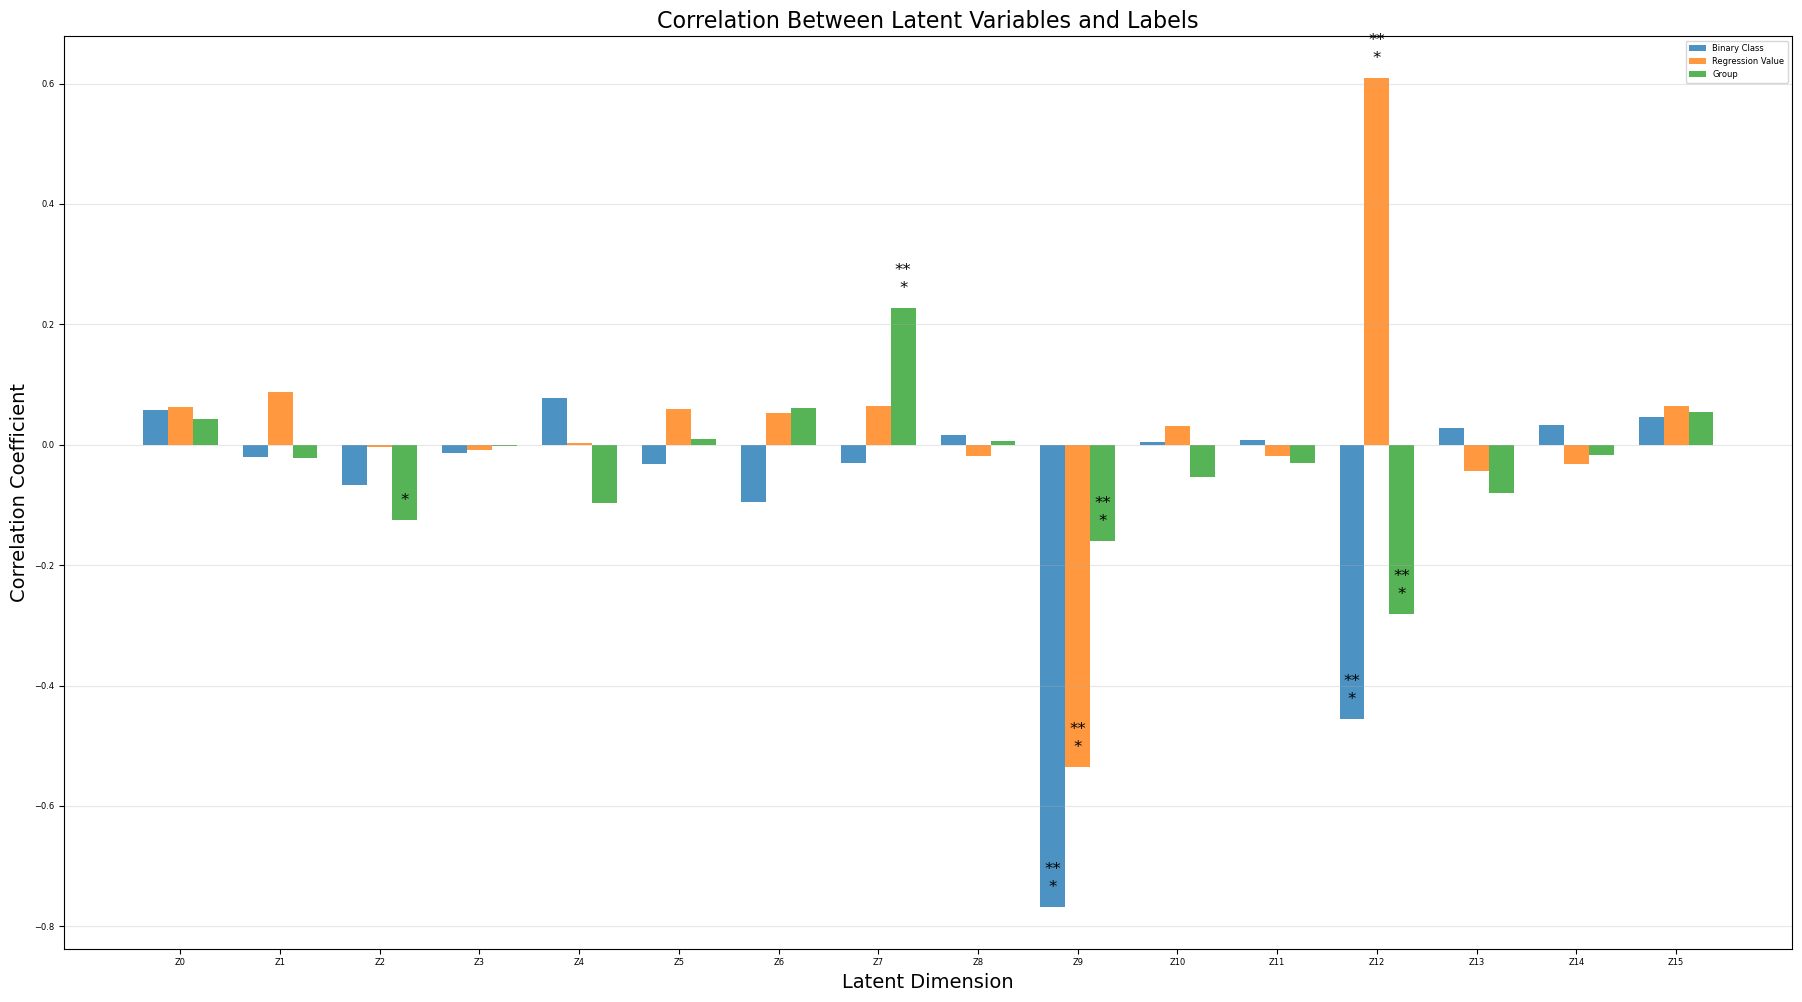


Binary Class correlations with latent variables:
  Z0: 0.0569 (p=0.2562)
  Z1: -0.0205 (p=0.6823)
  Z2: -0.0671 (p=0.1805)
  Z3: -0.0132 (p=0.7922)
  Z4: 0.0783 (p=0.1181)
  Z5: -0.0319 (p=0.5252)
  Z6: -0.0946 (p=0.0586)
  Z7: -0.0300 (p=0.5502)
  Z8: 0.0165 (p=0.7421)
  Z9: -0.7682 (significant) (p=0.0000)
  Z10: 0.0047 (p=0.9259)
  Z11: 0.0087 (p=0.8621)
  Z12: -0.4563 (significant) (p=0.0000)
  Z13: 0.0278 (p=0.5791)
  Z14: 0.0322 (p=0.5211)
  Z15: 0.0460 (p=0.3593)
  Top correlated dimensions: Z9 (0.7682), Z12 (0.4563), Z6 (0.0946)

Regression Value correlations with latent variables:
  Z0: 0.0632 (p=0.2070)
  Z1: 0.0874 (p=0.0809)
  Z2: -0.0043 (p=0.9312)
  Z3: -0.0085 (p=0.8647)
  Z4: 0.0025 (p=0.9606)
  Z5: 0.0591 (p=0.2385)
  Z6: 0.0524 (p=0.2959)
  Z7: 0.0636 (p=0.2041)
  Z8: -0.0191 (p=0.7029)
  Z9: -0.5352 (significant) (p=0.0000)
  Z10: 0.0316 (p=0.5289)
  Z11: -0.0187 (p=0.7095)
  Z12: 0.6095 (significant) (p=0.0000)
  Z13: -0.0430 (p=0.3914)
  Z14: -0.0314 (p=0.5316)
  

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

def calculate_correlations(latent_array, label_types):
    """
    Calculate correlations between latent variables and different types of labels
    
    Args:
        latent_array: Array of latent vectors (n_samples x n_dimensions)
        label_types: Dict of {label_name: label_array}
    
    Returns:
        Dictionary of correlation matrices for each label type
    """
    results = {}
    
    # Get number of latent dimensions
    n_dims = latent_array.shape[1]
    
    # Process each label type
    for label_name, labels in label_types.items():
        # Flatten labels
        flat_labels = labels.flatten()
        
        # Create correlation matrix
        corr_matrix = np.zeros(n_dims)
        p_values = np.zeros(n_dims)
        
        # Calculate correlation for each latent dimension
        for i in range(n_dims):
            latent_dim = latent_array[:, i]
            
            # For categorical labels with more than 2 categories, use point-biserial or eta correlation
            if label_name == "Group" and len(np.unique(flat_labels)) > 2:
                # Remap values to 0-based for easier processing (1,2 → 0,1)
                remapped_labels = flat_labels - np.min(flat_labels)
                
                # Method 1: For binary categorical, convert to dummy variables and use regular correlation
                # Calculate correlation for each category
                correlations = []
                for val in np.unique(remapped_labels):
                    binary = (remapped_labels == val).astype(float)
                    corr, p = stats.pearsonr(latent_dim, binary)
                    correlations.append(abs(corr))  # Take absolute value
                
                # Use the maximum correlation as the strength indicator
                corr_matrix[i] = max(correlations)
                
                # Alternative: Calculate eta correlation coefficient (correlation ratio)
                # This measures how well a categorical variable predicts a continuous one
                groups = [latent_dim[flat_labels == val] for val in np.unique(flat_labels)]
                ss_total = np.sum((latent_dim - np.mean(latent_dim))**2)
                ss_between = np.sum([len(g) * (np.mean(g) - np.mean(latent_dim))**2 for g in groups])
                eta_squared = ss_between / ss_total if ss_total > 0 else 0
                p_values[i] = 0.05  # Placeholder, eta doesn't have a direct p-value
                
                # Use eta as an alternative measure
                # corr_matrix[i] = np.sqrt(eta_squared)
                
            # For binary or continuous labels, use regular correlation
            else:
                # Check if the label is binary (0/1) or continuous
                if len(np.unique(flat_labels)) <= 2:
                    # Use point-biserial correlation (equivalent to Pearson for binary)
                    corr, p = stats.pointbiserialr(flat_labels, latent_dim)
                else:
                    # Use Pearson correlation for continuous values
                    corr, p = stats.pearsonr(flat_labels, latent_dim)
                
                corr_matrix[i] = corr
                p_values[i] = p
        
        results[label_name] = {
            'correlation': corr_matrix,
            'p_values': p_values
        }
    
    return results

# Prepare your labels
label_types = {
    'Binary Class': all_labels,
    'Regression Value': all_labels_reg,
    'Group': all_labels_group
}

# Calculate correlations
correlations = calculate_correlations(all_latents_array, label_types)

# Create a nice visualization of the correlations
plt.figure(figsize=(18, 10))

# Set up the plot
bar_width = 0.25
index = np.arange(all_latents_array.shape[1])
opacity = 0.8

# Plot each correlation type
for i, (label_name, corr_data) in enumerate(correlations.items()):
    # Get absolute correlation values for better comparison
    corr_values = corr_data['correlation']
    
    # Plot bars with different colors
    plt.bar(index + i*bar_width, corr_values, bar_width,
            alpha=opacity, color=f'C{i}', label=label_name)
    
    # Mark significant correlations with stars
    for j, p in enumerate(corr_data['p_values']):
        if p < 0.05:
            plt.text(j + i*bar_width, corr_values[j] + 0.02, '*', 
                     ha='center', va='bottom', fontsize=12)
        if p < 0.01:
            plt.text(j + i*bar_width, corr_values[j] + 0.05, '**', 
                     ha='center', va='bottom', fontsize=12)

# Add labels and legend
plt.xlabel('Latent Dimension', fontsize=14)
plt.ylabel('Correlation Coefficient', fontsize=14)
plt.title('Correlation Between Latent Variables and Labels', fontsize=16)
plt.xticks(index + bar_width, [f'Z{i}' for i in range(all_latents_array.shape[1])])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
##plt.savefig('latent_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a more detailed heatmap for each label type
for label_name, corr_data in correlations.items():
    # Print the correlation values
    print(f"\n{label_name} correlations with latent variables:")
    for i, corr in enumerate(corr_data['correlation']):
        p = corr_data['p_values'][i]
        sig = ' (significant)' if p < 0.05 else ''
        print(f"  Z{i}: {corr:.4f}{sig} (p={p:.4f})")
    
    # Identify most correlated dimensions
    abs_corrs = np.abs(corr_data['correlation'])
    top_dims = np.argsort(abs_corrs)[::-1][:3]  # Top 3 dimensions
    print(f"  Top correlated dimensions: {', '.join([f'Z{i} ({abs_corrs[i]:.4f})' for i in top_dims])}")

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import minmax_scale

def calculate_sap_scores(latent_array, label_types, visualization=True):
    """
    Calculate SAP scores for each label type using the Ubisoft implementation
    
    Args:
        latent_array: Array of latent vectors (n_samples x n_dimensions)
        label_types: Dict of {label_name: label_array}
        visualization: Whether to generate visualizations
        
    Returns:
        Dictionary of SAP scores and detailed score matrices
    """
    results = {}
    s_matrices = {}
    
    # Process each label type
    for label_name, label_array in label_types.items():
        # Determine factor type
        is_continuous = (len(np.unique(label_array)) > 10) or np.issubdtype(label_array.dtype, np.floating)
        is_binary = len(np.unique(label_array)) <= 2

        # Use appropriate SAP calculation
        if is_continuous:
            # Regression for continuous values
            score, s_matrix = calculate_sap_for_factor(
                label_array, latent_array, 
                continuous_factors=True, 
                regression=True
            )
        else:
            # Classification for binary/categorical
            score, s_matrix = calculate_sap_for_factor(
                label_array, latent_array, 
                continuous_factors=False, 
                regression=False
            )
        
        # Save results
        results[label_name] = score
        s_matrices[label_name] = s_matrix
    
    # Calculate normalized scores (0-1 range)
    normalized_results = {}
    for label_name, score in results.items():
        normalized_results[label_name] = min(max(score, 0.0), 1.0)
    
    # Generate visualizations
    if visualization:
        # Plot score matrices
        for label_name, s_matrix in s_matrices.items():
            plt.figure(figsize=(10, 4))
            plt.imshow(s_matrix, cmap='viridis', aspect='auto')
            plt.colorbar(label='Score')
            plt.xlabel('Latent Dimension')
            plt.ylabel('Factor')
            plt.title(f'SAP Score Matrix for {label_name}')
            plt.tight_layout()
            #plt.savefig(f'sap_matrix_{label_name.lower().replace(" ", "_")}.png', dpi=300)
            plt.close()
        
        # Plot original and normalized SAP scores
        plt.figure(figsize=(12, 6))
        
        # Set up bar plot
        labels = list(results.keys())
        x = np.arange(len(labels))
        width = 0.35
        
        # Original scores
        plt.bar(x - width/2, list(results.values()), width, label='Original SAP')
        
        # Normalized scores
        plt.bar(x + width/2, list(normalized_results.values()), width, label='Normalized SAP (0-1)')
        
        # Add labels
        plt.xlabel('Attribute Type', fontsize=14)
        plt.ylabel('SAP Score', fontsize=14)
        plt.title('SAP Scores by Attribute Type', fontsize=16)
        plt.xticks(x, labels)
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        #plt.savefig('sap_scores_comparison.png', dpi=300)
        plt.close()
    
    return {
        'original': results,
        'normalized': normalized_results,
        'matrices': s_matrices
    }

def calculate_sap_for_factor(factors, codes, continuous_factors=True, regression=True, nb_bins=10):
    """
    Calculate SAP for a single factor using the Ubisoft implementation
    
    Args:
        factors: Array of factor values
        codes: Array of latent codes
        continuous_factors: Whether the factor is continuous
        regression: Whether to use regression or classification
        nb_bins: Number of bins for discretization
        
    Returns:
        SAP score and score matrix
    """
    # Reshape inputs if needed
    if len(factors.shape) == 1:
        factors = factors.reshape(-1, 1)
    
    # Count dimensions
    nb_factors = factors.shape[1]
    nb_codes = codes.shape[1]
    
    # Calculate SAP matrices and scores
    if regression:
        assert continuous_factors, "Cannot perform SAP regression with discrete factors."
        s_matrix = np.zeros((nb_factors, nb_codes))
        
        # Calculate R2 score matrix
        for f in range(nb_factors):
            for c in range(nb_codes):
                # Train a linear regressor
                regr = LinearRegression()
                regr.fit(codes[:, c].reshape(-1, 1), factors[:, f].reshape(-1, 1))
                
                # Make predictions
                y_pred = regr.predict(codes[:, c].reshape(-1, 1))
                
                # Compute R2 score
                r2 = r2_score(factors[:, f], y_pred)
                s_matrix[f, c] = max(0, r2)
        
    else:
        # For classification
        # Quantize factors if continuous
        if continuous_factors:
            factors_norm = minmax_scale(factors.copy())  # normalize to [0,1]
            factors_quantized = np.zeros_like(factors_norm, dtype=int)
            for f in range(factors_norm.shape[1]):
                factors_quantized[:, f] = get_bin_index(factors_norm[:, f], nb_bins)
            factors = factors_quantized
        
        # Normalize codes to [0,1]
        codes_norm = minmax_scale(codes.copy())
        
        # Calculate accuracy matrix
        s_matrix = np.zeros((nb_factors, nb_codes))
        for f in range(nb_factors):
            for c in range(nb_codes):
                # Find optimal tree depth
                best_score, best_sp = 0, 0
                for sp in range(1, 10):
                    # Cross-validation
                    clf = tree.DecisionTreeClassifier(max_depth=sp)
                    scores = cross_val_score(
                        clf, 
                        codes_norm[:, c].reshape(-1, 1), 
                        factors[:, f].reshape(-1, 1), 
                        cv=5
                    )
                    score = scores.mean()
                    
                    if score > best_score:
                        best_score = score
                        best_sp = sp
                
                # Train final model with best depth
                clf = tree.DecisionTreeClassifier(max_depth=best_sp)
                clf.fit(codes_norm[:, c].reshape(-1, 1), factors[:, f].reshape(-1, 1))
                
                # Make predictions
                y_pred = clf.predict(codes_norm[:, c].reshape(-1, 1))
                
                # Compute accuracy
                s_matrix[f, c] = accuracy_score(factors[:, f], y_pred)
    
    # Compute the gap for all factors
    sum_gap = 0
    for f in range(nb_factors):
        # Get difference between highest and second highest
        s_f = np.sort(s_matrix[f, :])
        if len(s_f) >= 2:
            sum_gap += s_f[-1] - s_f[-2]
        else:
            sum_gap += s_f[-1]
    
    # Compute mean gap
    sap_score = sum_gap / nb_factors
    
    return sap_score, s_matrix

def get_bin_index(x, nb_bins):
    """
    Discretize input variable
    
    Args:
        x: Input variable
        nb_bins: Number of bins for discretization
    
    Returns:
        Discretized variable
    """
    # Get bin limits
    bins = np.linspace(0, 1, nb_bins + 1)
    
    # Discretize input variable
    return np.digitize(x, bins[:-1], right=False).astype(int)

# Example usage with your data
label_types = {
    'Binary Class': all_labels,
    'Regression Value': all_labels_reg,
    'Group': all_labels_group
}

# Calculate SAP scores and generate visualizations
sap_results = calculate_sap_scores(all_latents_array, label_types)

# Print results
print("\nSAP Scores (Original Implementation):")
for label_name, score in sap_results['original'].items():
    print(f"{label_name}: {score:.4f}")


# Calculate per-dimension importance for each factor
print("\nMost important latent dimensions for each factor:")
for label_name, s_matrix in sap_results['matrices'].items():
    # Get the most important dimension for each factor
    for f in range(s_matrix.shape[0]):
        best_dim = np.argmax(s_matrix[f, :])
        score = s_matrix[f, best_dim]
        print(f"{label_name} - Factor {f}: Z{best_dim} (Score: {score:.4f})")


SAP Scores (Original Implementation):
Binary Class: 0.3819
Regression Value: 0.0850
Group: 0.0270

Most important latent dimensions for each factor:
Binary Class - Factor 0: Z9 (Score: 0.5901)
Regression Value - Factor 0: Z12 (Score: 0.3715)
Group - Factor 0: Z12 (Score: 0.0788)


In [13]:
print(f"SAP scores (attribute vae): {sap_score}")

SAP scores: 0.045454545454545414


In [11]:
print(f"SAP scores (contrastive one variable): {sap_score}")

SAP scores (contrastive one variable): 0.09090909090909094


In [ ]:
print(all_labels)

In [10]:
test_latents = np.load(path)

In [12]:
latent_min = np.min(test_latents, axis=0)
latent_max = np.max(test_latents, axis=0)

print("Minimum values for each latent variable:", latent_min)
print("Maximum values for each latent variable:", latent_max)

Minimum values for each latent variable: [-0.6954266  -1.1536734  -0.47461104 -0.4344825  -0.57577467 -0.46523276
 -0.24694285 -0.49584898 -0.4581654  -0.44499192 -0.51410025 -0.63719094
 -0.4197298  -0.55275875 -0.5489806  -0.5510489 ]
Maximum values for each latent variable: [0.40666306 0.5711539  0.56581724 0.51912546 0.47664177 0.38276148
 0.33223683 0.73687285 0.6121826  0.45838717 0.6537683  0.43149415
 0.3252261  0.3948623  0.5224641  0.36176726]


In [14]:
latent_mean = np.mean(test_latents, axis=0)
latent_std = np.std(test_latents, axis=0)

print("Mean for each latent variable:", latent_mean)
print("Standard deviation for each latent variable:", latent_std)

Mean for each latent variable: [-0.0676787  -0.35337508 -0.05779378 -0.01753479  0.0125681  -0.02355604
  0.06498463  0.08168843 -0.07228059  0.04351648 -0.02543143  0.05087868
 -0.04577363 -0.04326111  0.05849929  0.00062894]
Standard deviation for each latent variable: [0.34588236 0.472742   0.28920478 0.24459042 0.2886332  0.21806082
 0.1952848  0.3078662  0.29442194 0.2431323  0.27060866 0.26424357
 0.21766897 0.2828115  0.2795713  0.23889777]


In [ ]:
# Loop over each latent variable and display the plot
for i in range(all_latents_array.shape[1]):
    plt.figure()
    plt.hist(all_latents_array[:, i], bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f"Distribution of Latent Variable {i}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    
    # Show the plot inline in the notebook
    plt.show()

In [23]:
for test_fname in eval_test_filenames:
    save_name = os.path.basename(test_fname).split(".npz")[0]
    mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
    test_surface_points = data.get_surface_points(mesh_path)
    test_surface_points = torch.from_numpy(test_surface_points)
    test_surface_points = test_surface_points.unsqueeze(0)
    label = labels.get(save_name)
    all_labels.append(label[0])
    all_labels_reg.append(label[2])
    all_labels_group.append(label[4])
    mesh_label_names.append(save_name)
    path = os.path.join(experiment_directory, "contrastive", ws.tb_logs_test_reconstructions, save_name)
    if not os.path.exists(path):
        os.makedirs(path)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import LocallyLinearEmbedding
from itertools import combinations
from scipy.stats import pearsonr, pointbiserialr
from sklearn.preprocessing import StandardScaler

def perform_comprehensive_dimensionality_reduction(data, n_components=5):
    """
    Perform PCA, ICA, HLLE, and HLLE+ICA with comprehensive analysis
    
    Args:
        data: Input data array (n_samples x n_features)
        n_components: Number of components to extract
    
    Returns:
        Dictionary containing results from different methods
    """
    # Standardize the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    results = {}
    
    print("Starting dimensionality reduction methods...")
    
    # 1. PCA
    print("Performing PCA...")
    pca = PCA(n_components=n_components, random_state=42)
    pca_result = pca.fit_transform(data_scaled)
    results['PCA'] = {
        'data': pca_result,
        'explained_variance': pca.explained_variance_ratio_,
        'model': pca
    }
    
    # 2. ICA
    print("Performing ICA...")
    ica = FastICA(n_components=n_components, random_state=42, max_iter=1000)
    ica_result = ica.fit_transform(data_scaled)
    results['ICA'] = {
        'data': ica_result,
        'model': ica
    }
    
    # 3. HLLE (Hessian Eigenmap LLE)
    print("Performing HLLE...")
    try:
        # Start with more neighbors and reduce if needed
        n_neighbors = min(200, data.shape[0] - 1)
        hlle = LocallyLinearEmbedding(
            n_neighbors=n_neighbors, 
            n_components=n_components,
            method='hessian',
            eigen_solver='auto',
            random_state=42
        )
        hlle_result = hlle.fit_transform(data_scaled)
        results['HLLE'] = {
            'data': hlle_result,
            'model': hlle
        }
        print(f"HLLE successful with {n_neighbors} neighbors")
    except Exception as e:
        print(f"HLLE failed with {n_neighbors} neighbors: {e}")
        # Try with fewer neighbors
        try:
            n_neighbors = min(200, data.shape[0] - 1)
            hlle = LocallyLinearEmbedding(
                n_neighbors=n_neighbors, 
                n_components=n_components,
                method='hessian',
                eigen_solver='dense',
                random_state=42
            )
            hlle_result = hlle.fit_transform(data_scaled)
            results['HLLE'] = {
                'data': hlle_result,
                'model': hlle
            }
            print(f"HLLE successful with {n_neighbors} neighbors")
        except Exception as e2:
            print(f"HLLE failed again: {e2}")
            # Fallback to standard LLE
            try:
                lle = LocallyLinearEmbedding(
                    n_neighbors=min(200, data.shape[0] - 1), 
                    n_components=n_components,
                    method='standard',
                    random_state=42
                )
                lle_result = lle.fit_transform(data_scaled)
                results['LLE'] = {
                    'data': lle_result,
                    'model': lle
                }
                print("Fallback to standard LLE successful")
            except Exception as e3:
                print(f"All LLE methods failed: {e3}")
    
    # 4. HLLE + ICA Pipeline
    print("Performing HLLE + ICA pipeline...")
    if 'HLLE' in results:
        # Apply ICA on HLLE results
        try:
            ica_on_hlle = FastICA(n_components=min(n_components, results['HLLE']['data'].shape[1]), 
                                 random_state=42, max_iter=1000)
            hlle_ica_result = ica_on_hlle.fit_transform(results['HLLE']['data'])
            results['HLLE+ICA'] = {
                'data': hlle_ica_result,
                'model': ica_on_hlle,
                'preprocessing': results['HLLE']['model']
            }
            print("HLLE + ICA pipeline successful")
        except Exception as e:
            print(f"HLLE + ICA failed: {e}")
    elif 'LLE' in results:
        # Use LLE + ICA as fallback
        try:
            ica_on_lle = FastICA(n_components=min(n_components, results['LLE']['data'].shape[1]), 
                                random_state=42, max_iter=1000)
            lle_ica_result = ica_on_lle.fit_transform(results['LLE']['data'])
            results['LLE+ICA'] = {
                'data': lle_ica_result,
                'model': ica_on_lle,
                'preprocessing': results['LLE']['model']
            }
            print("LLE + ICA fallback successful")
        except Exception as e:
            print(f"LLE + ICA fallback failed: {e}")
    
    return results

def calculate_component_label_correlations(results, labels_dict):
    """
    Calculate correlations between each method's components and all label types
    """
    print("\n" + "="*60)
    print("COMPONENT-LABEL CORRELATION ANALYSIS")
    print("="*60)
    
    component_label_correlations = {}
    
    for method_name, method_result in results.items():
        components_data = method_result['data']
        method_correlations = {}
        
        print(f"\n{method_name} Components vs Labels:")
        print("-" * 40)
        
        for label_name, label_values in labels_dict.items():
            label_flat = label_values.flatten()
            n_components = components_data.shape[1]
            
            # Initialize correlation matrices
            corr_matrix = np.zeros(n_components)
            p_values = np.zeros(n_components)
            
            # Calculate correlation for each component
            for comp_idx in range(n_components):
                component_values = components_data[:, comp_idx]
                
                # Determine correlation type based on label characteristics
                unique_labels = np.unique(label_flat)
                is_binary = len(unique_labels) <= 2
                is_continuous = len(unique_labels) > 10 or np.issubdtype(label_flat.dtype, np.floating)
                
                if is_binary:
                    # Use point-biserial correlation for binary labels
                    corr, p = pointbiserialr(label_flat, component_values)
                elif is_continuous:
                    # Use Pearson correlation for continuous labels
                    corr, p = pearsonr(label_flat, component_values)
                else:
                    # For categorical with few categories, calculate eta correlation
                    # Use the maximum correlation across all category combinations
                    correlations = []
                    for val in unique_labels:
                        binary = (label_flat == val).astype(float)
                        corr_temp, _ = pearsonr(binary, component_values)
                        correlations.append(abs(corr_temp))
                    corr = max(correlations)
                    p = 0.05  # Placeholder p-value
                
                corr_matrix[comp_idx] = corr
                p_values[comp_idx] = p
            
            method_correlations[label_name] = {
                'correlations': corr_matrix,
                'p_values': p_values
            }
            
            # Print results for this label type
            print(f"\n  {label_name}:")
            for comp_idx in range(n_components):
                corr = corr_matrix[comp_idx]
                p = p_values[comp_idx]
                sig = " *" if p < 0.05 else ""
                sig += " **" if p < 0.01 else ""
                print(f"    Comp{comp_idx+1}: r={corr:.4f} (p={p:.4f}){sig}")
            
            # Find most correlated component
            best_comp = np.argmax(np.abs(corr_matrix))
            print(f"    Best component: Comp{best_comp+1} (r={corr_matrix[best_comp]:.4f})")
        
        component_label_correlations[method_name] = method_correlations
    
    return component_label_correlations

def create_comprehensive_heatmaps(correlations, save_prefix="correlation_analysis"):
    """
    Create comprehensive heatmaps for all correlation matrices
    """
    print("\n" + "="*60)
    print("GENERATING CROSS-METHOD CORRELATION HEATMAPS")
    print("="*60)
    
    for corr_name, corr_matrix in correlations.items():
        if 'pvalues' in corr_name:
            continue  # Skip p-value matrices for visualization
        
        plt.figure(figsize=(12, 10))
        
        # Create appropriate labels
        if 'internal' in corr_name:
            method = corr_name.replace('_internal', '')
            labels = [f'Comp{i+1}' for i in range(corr_matrix.shape[0])]
            title = f'{method} Internal Component Correlations'
            
            # Create heatmap with diagonal mask for internal correlations
            mask = np.eye(corr_matrix.shape[0], dtype=bool)
            sns.heatmap(
                corr_matrix,
                annot=True,
                cmap='RdBu_r',
                center=0,
                vmin=-1,
                vmax=1,
                xticklabels=labels,
                yticklabels=labels,
                fmt='.3f',
                mask=mask,
                square=True
            )
        else:
            methods = corr_name.split('_vs_')
            row_labels = [f'{methods[0]}_Comp{i+1}' for i in range(corr_matrix.shape[0])]
            col_labels = [f'{methods[1]}_Comp{i+1}' for i in range(corr_matrix.shape[1])]
            title = f'{methods[0]} vs {methods[1]} Cross-Method Correlations'
            
            sns.heatmap(
                corr_matrix,
                annot=True,
                cmap='RdBu_r',
                center=0,
                vmin=-1,
                vmax=1,
                xticklabels=col_labels,
                yticklabels=row_labels,
                fmt='.3f'
            )
        
        plt.title(title, fontsize=16)
        plt.tight_layout()
        #plt.savefig(f'{save_prefix}_{corr_name}.png', dpi=300, bbox_inches='tight')
        plt.show()

def plot_all_pairwise_components(results, labels_dict, save_prefix="dimensionality_analysis"):
    """
    Create comprehensive pairwise scatter plots for all components and methods
    """
    for method_name, method_result in results.items():
        components_data = method_result['data']
        n_components = components_data.shape[1]
        
        print(f"\nGenerating pairwise plots for {method_name}...")
        
        # For each label type
        for label_name, label_values in labels_dict.items():
            # Calculate number of pairwise combinations
            n_pairs = n_components * (n_components - 1) // 2
            if n_pairs == 0:
                continue
                
            # Set up subplot grid
            cols = min(5, n_pairs)
            rows = (n_pairs + cols - 1) // cols
            
            fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
            
            # Handle different subplot configurations
            if n_pairs == 1:
                axes = [axes]
            elif rows == 1:
                axes = axes.reshape(1, -1) if cols > 1 else [axes]
            elif cols == 1:
                axes = axes.reshape(-1, 1)
            
            plot_idx = 0
            
            # Generate all pairwise combinations
            for i in range(n_components):
                for j in range(i+1, n_components):
                    if plot_idx >= n_pairs:
                        break
                        
                    row = plot_idx // cols
                    col = plot_idx % cols
                    
                    if rows > 1:
                        ax = axes[row, col] if cols > 1 else axes[row, 0]
                    else:
                        ax = axes[col] if cols > 1 else axes[0]
                    
                    # Determine color scheme
                    label_flat = label_values.flatten()
                    is_continuous = len(np.unique(label_flat)) > 10 or np.issubdtype(label_flat.dtype, np.floating)
                    
                    # Create scatter plot
                    if is_continuous:
                        scatter = ax.scatter(
                            components_data[:, i], 
                            components_data[:, j],
                            c=label_flat,
                            cmap='plasma',
                            alpha=0.7,
                            s=50,
                            edgecolors='black',
                            linewidth=0.5
                        )
                        plt.colorbar(scatter, ax=ax, shrink=0.8)
                    else:
                        unique_vals = np.unique(label_flat)
                        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_vals)))
                        for idx, val in enumerate(unique_vals):
                            mask = label_flat == val
                            ax.scatter(
                                components_data[mask, i], 
                                components_data[mask, j],
                                c=[colors[idx]],
                                alpha=0.7,
                                s=50,
                                edgecolors='black',
                                linewidth=0.5,
                                label=f'{val}'
                            )
                        if plot_idx == 0:  # Add legend only to first plot
                            ax.legend(title=label_name, bbox_to_anchor=(1.05, 1), loc='upper left')
                    
                    ax.set_xlabel(f'{method_name} Component {i+1}')
                    ax.set_ylabel(f'{method_name} Component {j+1}')
                    ax.set_title(f'Comp{i+1} vs Comp{j+1}')
                    ax.grid(True, alpha=0.3)
                    
                    plot_idx += 1
            
            # Hide unused subplots
            for idx in range(plot_idx, rows * cols):
                row = idx // cols
                col = idx % cols
                if rows > 1:
                    ax = axes[row, col] if cols > 1 else axes[row, 0]
                else:
                    ax = axes[col] if cols > 1 else axes[0]
                ax.set_visible(False)
            
            plt.suptitle(f'{method_name} Pairwise Component Analysis - {label_name}', fontsize=16)
            plt.tight_layout()
            #plt.savefig(f'{save_prefix}_{method_name}_{label_name.lower().replace(" ", "_")}_pairwise.png', dpi=300, bbox_inches='tight')
            plt.show()

def analyze_explained_variance(results):
    """
    Analyze and plot explained variance for methods that support it
    """
    print("\n" + "="*60)
    print("EXPLAINED VARIANCE ANALYSIS")
    print("="*60)
    
    for method_name, method_result in results.items():
        if 'explained_variance' in method_result:
            explained_var = method_result['explained_variance']
            cumulative_var = np.cumsum(explained_var)
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
            
            # Individual explained variance
            bars = ax1.bar(range(1, len(explained_var)+1), explained_var, alpha=0.7, color='steelblue')
            ax1.set_xlabel('Component')
            ax1.set_ylabel('Explained Variance Ratio')
            ax1.set_title(f'{method_name} - Individual Explained Variance')
            ax1.grid(True, alpha=0.3)
            
            # Add value labels on bars
            for i, bar in enumerate(bars):
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                        f'{explained_var[i]:.3f}', ha='center', va='bottom')
            
            # Cumulative explained variance
            ax2.plot(range(1, len(cumulative_var)+1), cumulative_var, 'bo-', linewidth=2, markersize=8)
            ax2.set_xlabel('Number of Components')
            ax2.set_ylabel('Cumulative Explained Variance Ratio')
            ax2.set_title(f'{method_name} - Cumulative Explained Variance')
            ax2.grid(True, alpha=0.3)
            ax2.set_ylim(0, 1)
            
            # Add value labels on points
            for i, val in enumerate(cumulative_var):
                ax2.text(i+1, val + 0.02, f'{val:.3f}', ha='center', va='bottom')
            
            plt.tight_layout()
            #plt.savefig(f'explained_variance_{method_name}.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print(f"\n{method_name} Explained Variance:")
            for i, var in enumerate(explained_var):
                print(f"  Component {i+1}: {var:.4f} ({var*100:.2f}%)")
            print(f"  Total variance explained: {cumulative_var[-1]:.4f} ({cumulative_var[-1]*100:.2f}%)")

def create_summary_correlation_plot(component_label_correlations):
    """
    Create a summary plot showing the best component-label correlations for each method
    """
    print("\n" + "="*60)
    print("GENERATING SUMMARY CORRELATION PLOT")
    print("="*60)
    
    methods = list(component_label_correlations.keys())
    label_types = list(component_label_correlations[methods[0]].keys())
    
    # Find best correlation for each method-label combination
    best_correlations = np.zeros((len(methods), len(label_types)))
    best_components = np.zeros((len(methods), len(label_types)), dtype=int)
    
    for i, method in enumerate(methods):
        for j, label_type in enumerate(label_types):
            correlations = component_label_correlations[method][label_type]['correlations']
            best_idx = np.argmax(np.abs(correlations))
            best_correlations[i, j] = correlations[best_idx]
            best_components[i, j] = best_idx + 1  # 1-indexed
    
    # Create heatmap
    plt.figure(figsize=(12, 8))
    
    # Create annotations with component numbers
    annotations = []
    for i in range(len(methods)):
        row_annotations = []
        for j in range(len(label_types)):
            corr_val = best_correlations[i, j]
            comp_num = best_components[i, j]
            annotation = f'{corr_val:.3f}\n(Comp{comp_num})'
            row_annotations.append(annotation)
        annotations.append(row_annotations)
    
    sns.heatmap(
        best_correlations,
        annot=annotations,
        fmt='',
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        xticklabels=label_types,
        yticklabels=methods,
        cbar_kws={'label': 'Best Correlation Coefficient'}
    )
    
    plt.title('Best Component-Label Correlations by Method\n(Component number in parentheses)', fontsize=14)
    plt.xlabel('Label Types', fontsize=12)
    plt.ylabel('Dimensionality Reduction Methods', fontsize=12)
    plt.tight_layout()
    #plt.savefig('summary_best_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()

# Main execution
print("=" * 80)
print("COMPREHENSIVE DIMENSIONALITY REDUCTION ANALYSIS")
print("=" * 80)

# Check if data is available
try:
    # Try to use existing all_latents_array
    print(f"Using existing all_latents_array with shape: {all_latents_array.shape}")
except NameError:
    try:
        # Try to load from file
        latents_path = os.path.join(experiment_directory, "metrics", "all_latents.npy")
        all_latents_array = np.load(latents_path)
        all_latents_array = all_latents_array.squeeze()
        print(f"Loaded all_latents_array from file with shape: {all_latents_array.shape}")
    except:
        print("Error: Could not find latent data. Please run earlier cells to generate all_latents_array.")
        raise

# Prepare labels dictionary
all_labels = np.array(all_labels)
all_labels = all_labels.reshape(-1, 1)
all_labels_reg = np.array(all_labels_reg)
all_labels_reg = all_labels_reg.reshape(-1, 1)
all_labels_group = np.array(all_labels_group)
all_labels_group = all_labels_group.reshape(-1, 1)
try:
    labels_dict = {
        'Binary Class': all_labels,
        'Regression Value': all_labels_reg, 
        'Group': all_labels_group
    }
    print(f"Using labels with shapes:")
    for name, labels in labels_dict.items():
        print(f"  {name}: {labels.shape}")
except NameError:
    print("Error: Labels not found. Please run earlier cells to generate label arrays.")
    raise

# Perform dimensionality reduction
print(f"\nInput data shape: {all_latents_array.shape}")
results = perform_comprehensive_dimensionality_reduction(all_latents_array, n_components=5)

print(f"\nSuccessfully computed {len(results)} dimensionality reduction methods:")
for method in results.keys():
    print(f"  - {method}: shape {results[method]['data'].shape}")

# 1. Analyze explained variance
analyze_explained_variance(results)

# 2. Calculate component-label correlations
component_label_correlations = calculate_component_label_correlations(results, labels_dict)

# 4. Create summary correlation plot
create_summary_correlation_plot(component_label_correlations)

# 7. Create pairwise component plots
print("\n" + "="*60)
print("GENERATING PAIRWISE COMPONENT PLOTS")
print("="*60)
plot_all_pairwise_components(results, labels_dict)


VAE LATENT DIAGNOSTICS

1. Checking for Posterior Collapse:
Latent means: [ 9.1593445e-04 -4.7063094e-04  2.7318972e-03 -4.8729647e-03
 -1.1226320e-05  3.6839820e-03  2.0113715e-03 -2.9808425e-03
 -1.3946892e-03 -3.0494971e-02 -2.1115104e-03 -1.7629117e-04
  2.0150607e-02 -8.4860181e-04 -2.1172091e-03 -2.5889296e-03]
Latent stds: [0.02469608 0.02211609 0.01858837 0.01910165 0.02155325 0.01663818
 0.02362292 0.02035976 0.02072624 0.3969388  0.02432906 0.01941249
 0.39635462 0.02626161 0.02113574 0.02247401]

2. Checking Latent Utilization:
Effective dimensions (std > 0.1): 2/16
⚠️  LOW LATENT UTILIZATION!
   Many latent dimensions are underutilized

3. Analyzing Latent Structure:


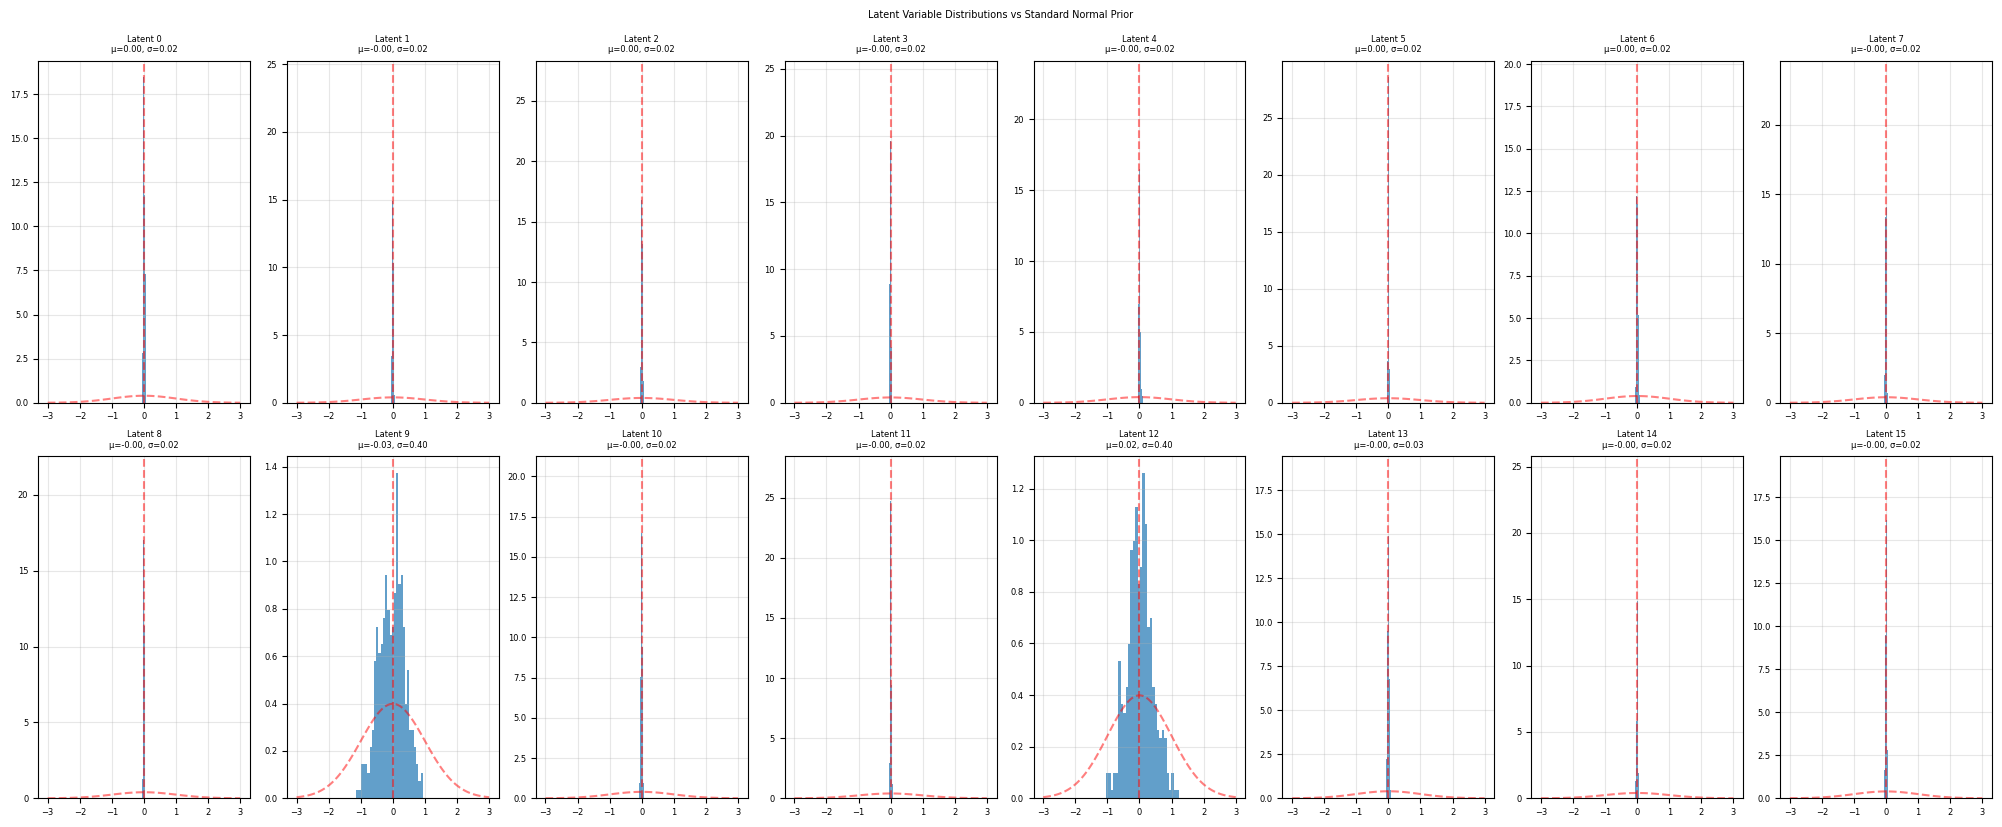


SUGGESTED IMPROVEMENTS

🔧 For Low Latent Utilization:
   1. Use spectral normalization
   2. Add batch normalization
   3. Increase model capacity
   4. Use factor-VAE or β-TC-VAE objectives

🔧 For Better Disentanglement:
   1. Add supervised loss terms:
      - Classifier loss on latents
      - Contrastive loss
      - Attribute prediction heads
   2. Use different VAE variants:
      - β-VAE for controlled disentanglement
      - Factor-VAE for factor disentanglement
      - DCI-VAE for interpretable factors

🔧 Example Modified Training Config:

# Modified specs for better disentanglement
{
    "NetworkArch": "sdf_vae", 
    "KLWeight": 0.1,  # Reduced from 1.0
    "SupervisionWeight": 1.0,  # Add supervision
    "ContrastiveWeight": 0.5,  # Add contrastive learning
    "LatentDim": 32,  # Increase capacity
    "UseSpectralNorm": true,
    "KLAnnealing": {
        "start_epoch": 0,
        "end_epoch": 100,
        "start_weight": 0.0,
        "end_weight": 0.1
    }
}



In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def diagnose_vae_latents(all_latents_array, labels_dict):
    """
    Diagnose issues with VAE latent representations
    """
    print("=" * 60)
    print("VAE LATENT DIAGNOSTICS")
    print("=" * 60)
    
    # 1. Check for posterior collapse
    print("\n1. Checking for Posterior Collapse:")
    latent_means = np.mean(all_latents_array, axis=0)
    latent_stds = np.std(all_latents_array, axis=0)
    
    print(f"Latent means: {latent_means}")
    print(f"Latent stds: {latent_stds}")
    
    # Check if latents are too close to standard normal
    mean_close_to_zero = np.all(np.abs(latent_means) < 0.1)
    std_close_to_one = np.all(np.abs(latent_stds - 1.0) < 0.1)
    
    if mean_close_to_zero and std_close_to_one:
        print("⚠️  POTENTIAL POSTERIOR COLLAPSE DETECTED!")
        print("   Latents are too close to N(0,1) prior")
    
    # 2. Check latent utilization
    print("\n2. Checking Latent Utilization:")
    effective_dims = np.sum(latent_stds > 0.1)  # Dimensions with meaningful variance
    print(f"Effective dimensions (std > 0.1): {effective_dims}/{len(latent_stds)}")
    
    if effective_dims < len(latent_stds) * 0.5:
        print("⚠️  LOW LATENT UTILIZATION!")
        print("   Many latent dimensions are underutilized")
    
    # 3. Check reconstruction vs KL trade-off
    print("\n3. Analyzing Latent Structure:")
    
    # Plot latent distributions
    fig, axes = plt.subplots(2, 8, figsize=(20, 8))
    for i in range(min(16, all_latents_array.shape[1])):
        row = i // 8
        col = i % 8
        
        axes[row, col].hist(all_latents_array[:, i], bins=30, alpha=0.7, density=True)
        axes[row, col].axvline(0, color='red', linestyle='--', alpha=0.5, label='Prior mean')
        axes[row, col].set_title(f'Latent {i}\nμ={latent_means[i]:.2f}, σ={latent_stds[i]:.2f}')
        axes[row, col].grid(True, alpha=0.3)
        
        # Overlay standard normal for comparison
        x = np.linspace(-3, 3, 100)
        axes[row, col].plot(x, np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi), 
                           'r--', alpha=0.5, label='N(0,1)')
    
    plt.tight_layout()
    plt.suptitle('Latent Variable Distributions vs Standard Normal Prior', y=1.02)
    plt.show()
    
    return {
        'posterior_collapse': mean_close_to_zero and std_close_to_one,
        'effective_dimensions': effective_dims,
        'latent_means': latent_means,
        'latent_stds': latent_stds
    }

def suggest_improvements(diagnostics, experiment_directory):
    """
    Suggest improvements based on diagnostics
    """
    print("\n" + "=" * 60)
    print("SUGGESTED IMPROVEMENTS")
    print("=" * 60)
    
    if diagnostics['posterior_collapse']:
        print("\n🔧 For Posterior Collapse:")
        print("   1. Reduce KL weight (β-VAE with β < 1)")
        print("   2. Use KL annealing during training")
        print("   3. Add skip connections in decoder")
        print("   4. Increase latent dimension")
    
    if diagnostics['effective_dimensions'] < 8:
        print("\n🔧 For Low Latent Utilization:")
        print("   1. Use spectral normalization")
        print("   2. Add batch normalization")
        print("   3. Increase model capacity")
        print("   4. Use factor-VAE or β-TC-VAE objectives")
    
    print("\n🔧 For Better Disentanglement:")
    print("   1. Add supervised loss terms:")
    print("      - Classifier loss on latents")
    print("      - Contrastive loss")
    print("      - Attribute prediction heads")
    print("   2. Use different VAE variants:")
    print("      - β-VAE for controlled disentanglement")
    print("      - Factor-VAE for factor disentanglement")
    print("      - DCI-VAE for interpretable factors")
    
    # Generate example configuration
    print("\n🔧 Example Modified Training Config:")
    config_example = f"""
# Modified specs for better disentanglement
{{
    "NetworkArch": "sdf_vae", 
    "KLWeight": 0.1,  # Reduced from 1.0
    "SupervisionWeight": 1.0,  # Add supervision
    "ContrastiveWeight": 0.5,  # Add contrastive learning
    "LatentDim": {diagnostics['latent_means'].shape[0] * 2},  # Increase capacity
    "UseSpectralNorm": true,
    "KLAnnealing": {{
        "start_epoch": 0,
        "end_epoch": 100,
        "start_weight": 0.0,
        "end_weight": 0.1
    }}
}}
"""
    print(config_example)

# Run diagnostics
diagnostics = diagnose_vae_latents(all_latents_array, labels_dict)
suggest_improvements(diagnostics, experiment_directory)